In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
df

,Year,Month,Month_Name,Oil,Coal_Lignite,Natural_Gas,Total_CO2
0,1987,1,JAN,2887.26,703.79,522.03,4113.08
1,1987,2,FEB,2506.05,697.51,523.50,3727.06
2,1987,3,MAR,2756.09,686.68,605.84,4048.62
3,1987,4,APR,2699.84,741.40,593.62,4034.86
4,1987,5,MAY,2740.84,1370.03,678.79,4789.66
...,...,...,...,...,...,...,...
466,2025,11,NOV,8638.57,4501.77,5847.82,18988.16
467,2025,12,DEC,9350.42,4518.88,6248.92,20118.22
468,2026,1,JAN,9258.40,3488.06,6339.66,19086.12
469,2026,2,FEB,8498.87,3755.73,6653.14,18907.74


In [3]:
monthly = df.groupby(['Year', 'Month'])['Total_CO2'].sum().reset_index()

In [4]:
monthly

,Year,Month,Total_CO2
0,1987,1,4113.08
1,1987,2,3727.06
2,1987,3,4048.62
3,1987,4,4034.86
4,1987,5,4789.66
...,...,...,...
466,2025,11,18988.16
467,2025,12,20118.22
468,2026,1,19086.12
469,2026,2,18907.74


In [5]:
# =========================================================
# TIME-SERIES TRAIN / TEST SPLIT
# =========================================================
# Train : all data before January 2024  (1987-01 → 2023-12)
# Test  : January 2024 onward
#
# This preserves temporal order — no data leakage.
# =========================================================

# rows BEFORE Jan 2024 go to train
train_mask = (monthly['Year'] < 2024) | \
             ((monthly['Year'] == 2024) & (monthly['Month'] < 1))

train_data = monthly[monthly['Year'] < 2024].copy()
test_data  = monthly[
    (monthly['Year'] > 2024) |
    ((monthly['Year'] == 2024) & (monthly['Month'] >= 1))
].copy()

print(f"Train period : {train_data['Year'].min()}-{train_data['Month'].min():02d}  "
      f"→  {train_data['Year'].max()}-{train_data['Month'].max():02d}  "
      f"({len(train_data)} months)")
print(f"Test  period : {test_data['Year'].min()}-{test_data['Month'].min():02d}  "
      f"→  {test_data['Year'].max()}-{test_data['Month'].max():02d}  "
      f"({len(test_data)} months)")

Train period : 1987-01  →  2023-12  (444 months)
Test  period : 2024-01  →  2026-12  (27 months)


In [6]:
X_train = train_data[['Year', 'Month']]
y_train = train_data['Total_CO2']

X_test  = test_data[['Year', 'Month']]
y_test  = test_data['Total_CO2']

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)
y_pred

array([24275.76997286, 24278.03212084, 24280.29426883, 24282.55641682,
       24284.81856481, 24287.08071279, 24289.34286078, 24291.60500877,
       24293.86715675, 24296.12930474, 24298.39145273, 24300.65360072,
       24759.68342275, 24761.94557074, 24764.20771873, 24766.46986672,
       24768.7320147 , 24770.99416269, 24773.25631068, 24775.51845866,
       24777.78060665, 24780.04275464, 24782.30490263, 24784.56705061,
       25243.59687265, 25245.85902064, 25248.12116863])

In [9]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2   = r2_score(y_test, y_pred)

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAPE     : {mape:.4f} %")
print(f"R²       : {r2:.4f}")

MAE      : 4428.8630
MSE      : 20761578.7909
RMSE     : 4556.4875
MAPE     : 22.2234 %
R²       : -22.6807


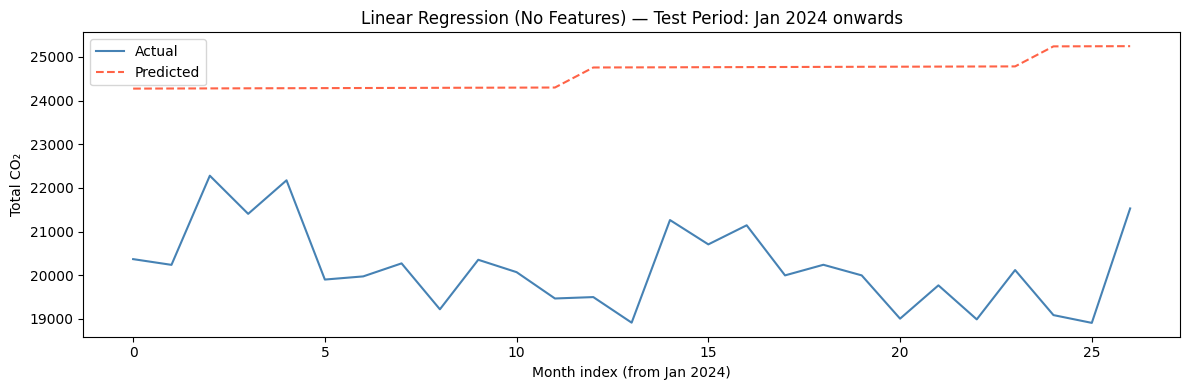

In [10]:
# Actual vs Predicted on test set
test_index = range(len(y_test))

plt.figure(figsize=(12, 4))
plt.plot(test_index, y_test.values, label='Actual',    color='steelblue')
plt.plot(test_index, y_pred,          label='Predicted', color='tomato', linestyle='--')
plt.title('Linear Regression (No Features) — Test Period: Jan 2024 onwards')
plt.xlabel('Month index (from Jan 2024)')
plt.ylabel('Total CO₂')
plt.legend()
plt.tight_layout()
plt.show()